**Improving Candidate Placement Success Rate**

**Import Libraries**

In [28]:
!pip install gdown

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown

**Load Dataset**


In [29]:
file_id = "1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp"

download_url = f"https://drive.google.com/uc?id={file_id}"

output_file = "Placed_dataset.csv"

gdown.download(download_url,"Placed_dataset.csv",quiet=False)

df=pd.read_csv("Placed_dataset.csv")

Downloading...
From (original): https://drive.google.com/uc?id=1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp
From (redirected): https://drive.google.com/uc?id=1M7aRHzeR7HKjMz-kImOTRuA5S0VUE3Pp&confirm=t&uuid=90c89b48-7bf0-437f-b30d-14687ef11594
To: /content/Placed_dataset.csv
100%|██████████| 181M/181M [00:02<00:00, 84.6MB/s]


**To check the dataset has been imported or not**

In [30]:
df.head()
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   age                    1000000 non-null  int64  
 1   cgpa                   1000000 non-null  float64
 2   backlogs               1000000 non-null  int64  
 3   attendance             1000000 non-null  float64
 4   tenth_percentage       1000000 non-null  float64
 5   twelfth_percentage     1000000 non-null  float64
 6   branch                 1000000 non-null  object 
 7   college_tier           1000000 non-null  int64  
 8   python_skill           1000000 non-null  int64  
 9   c++_skill              1000000 non-null  int64  
 10  java_skill             1000000 non-null  int64  
 11  ml_skill               1000000 non-null  int64  
 12  web_dev_skill          1000000 non-null  int64  
 13  communication_skill    1000000 non-null  int64  
 14  aptitude_score     

(1000000, 30)

**Function for finding whether there are any missing values present in the dataset or not.**

In [31]:
df.isnull().sum()

,0
age,0
cgpa,0
backlogs,0
attendance,0
tenth_percentage,0
twelfth_percentage,0
branch,0
college_tier,0
python_skill,0
c++_skill,0


**To check for duplicate rows**

In [32]:
df.duplicated().sum()

np.int64(0)

Duplicate value check was performed using df.duplicated().sum(). No duplicate records were identified in the dataset.

**North Star Metric Placement Success Rate**

In [33]:
# North Star Metric Calculation

total_students = len(df)

placed_students = df['placed'].sum()

placement_success_rate = (placed_students / total_students) * 100

print("Total Students:", total_students)
print("Placed Students:", placed_students)
print("Placement Success Rate:", round(placement_success_rate,2), "%")

Total Students: 1000000
Placed Students: 500159
Placement Success Rate: 50.02 %


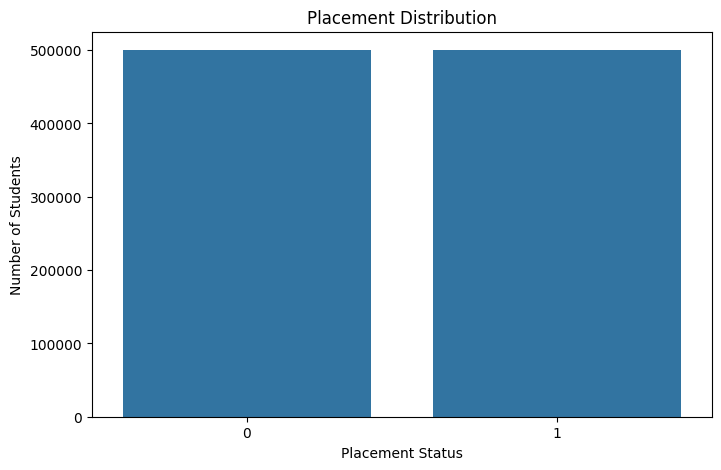

In [34]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='placed',
    data=df
)

plt.title("Placement Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")

plt.show()

The placement success rate represents the overall effectiveness of candidate conversion where 0 = 'Not Placed' and 1 = 'Placed'.

Normalising values

In [35]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

cols = [ 'cgpa', 'aptitude_score', 'python_skill', 'coding_contest_rating']

df[cols] = scaler.fit_transform(df[cols])

Normalization was applied to selected numerical features using Min-Max Scaling to bring all variables to a common scale between 0 and 1. The result is shown below with the help of table.

In [36]:
df.head(5)

,age,cgpa,backlogs,attendance,tenth_percentage,twelfth_percentage,branch,college_tier,python_skill,c++_skill,...,certifications,coding_contest_rating,teamwork,leadership,problem_solving,time_management,gender,city_tier,family_income,placed
0,23,0.588,3,84.656624,81.551017,54.282095,CSE,2,1.000000,8,...,0,0.252276,5,9,9,2,Female,1,7.849912,1
1,24,0.492,2,90.663809,71.742919,61.844316,IT,3,0.777778,6,...,1,0.336242,3,1,4,8,Female,2,8.621398,1
2,22,0.434,2,84.895718,87.972353,80.510087,CSE,1,0.333333,2,...,2,0.351140,6,0,6,5,Female,3,4.046578,0
3,24,0.654,2,69.347246,72.739454,88.699314,ECE,1,0.222222,5,...,3,0.398098,9,1,9,9,Female,2,8.676290,1
4,24,0.668,2,74.225862,45.648440,77.383406,CSE,2,0.333333,1,...,1,0.394210,9,0,7,7,Male,3,6.996345,0


Checking normalised values before segmentation

In [37]:
df[['cgpa','python_skill','communication_skill']].describe()

,cgpa,python_skill,communication_skill
count,1000000.000000,1000000.000000,1000000.000000
mean,0.499842,0.500376,4.503571
std,0.197641,0.319305,2.873887
min,0.000000,0.000000,0.000000
25%,0.366000,0.222222,2.000000
50%,0.500000,0.555556,5.000000
75%,0.634000,0.777778,7.000000
max,1.000000,1.000000,9.000000


**Segmentation**

In [38]:
conditions = [
    (df['cgpa'] >= 0.63) &
    (df['python_skill'] >= 0.77) &
    (df['communication_skill'] >= 7) &
    (df['internships'] >= 2),

    (df['cgpa'] >= 0.50) &
    (df['python_skill'] >= 0.55) &
    (df['communication_skill'] >= 5)
]

choices = [
    'High Potential',
    'Moderate Potential'
]

df['candidate_segment'] = np.select(
    conditions,
    choices,
    default='High Risk'
)

print(df['candidate_segment'].value_counts())

candidate_segment
High Risk             874283
Moderate Potential    115250
High Potential         10467
Name: count, dtype: int64


In [39]:
df.groupby('candidate_segment')['placed'].mean()*100

,placed
candidate_segment,
High Potential,70.335340
High Risk,48.478925
Moderate Potential,59.829935




*   75% CGPA = 0.634
*   75% Python Skill = 0.777
*   75% Communication = 7
*   Median CGPA = 0.50
*   Median Python = 0.556
*   Median Communication = 5

Candidate Segment Vs Placemnet

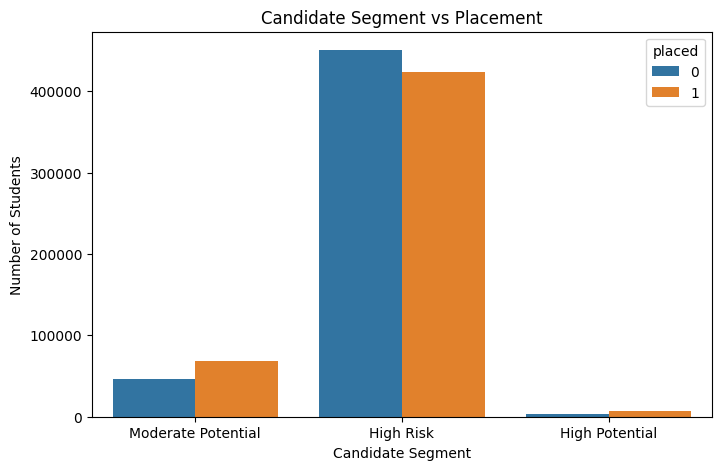

In [40]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='candidate_segment',
    hue='placed',
    data=df,
)

plt.title('Candidate Segment vs Placement')
plt.xlabel('Candidate Segment')
plt.ylabel('Number of Students')

plt.show()

Placement Rate by Candidate segment

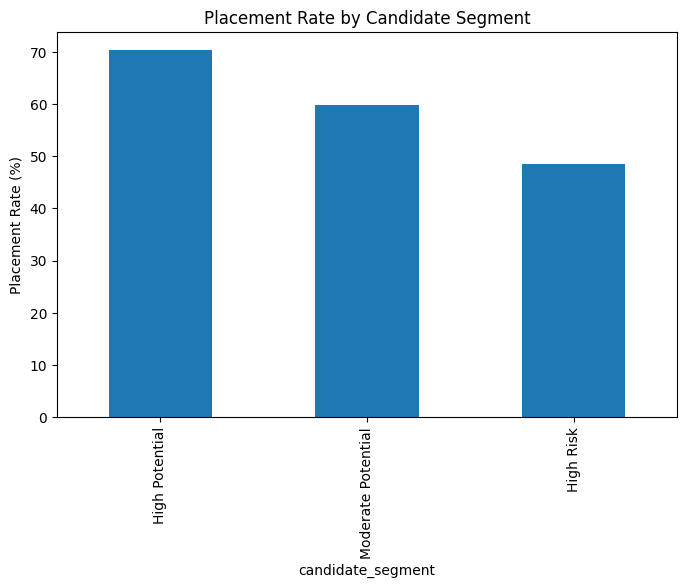

In [41]:
segment_rate = (
    df.groupby('candidate_segment')['placed']
      .mean()
      .mul(100)
      .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

segment_rate.plot(kind='bar')

plt.title('Placement Rate by Candidate Segment')
plt.ylabel('Placement Rate (%)')

plt.show()

*   High potential candidates have the highest rate of placment
*   Moderate Potential Candidates Show Average Success
*   High Risk Candidates Have the Lowest Placement Rate

**Conducting Exploratory Data Analysis (EDA)**

CGPA VS Placement

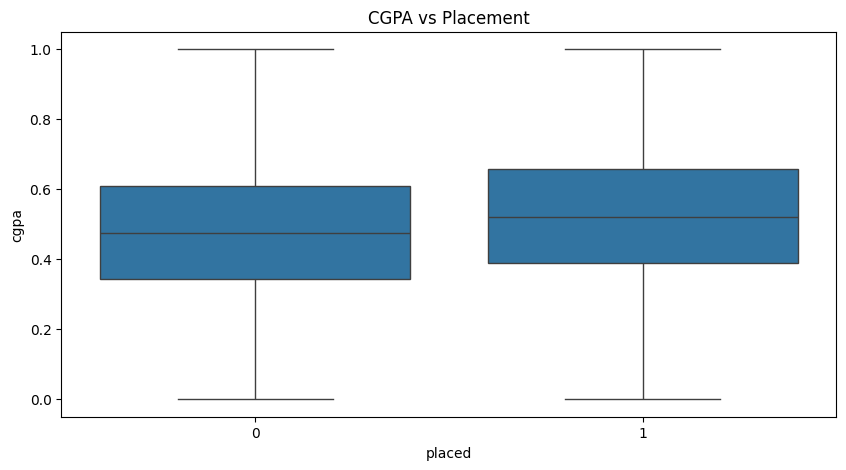

In [42]:
plt.figure(figsize=(10,5))

sns.boxplot(
x='placed',
y='cgpa',
data=df
)

plt.title("CGPA vs Placement")
plt.show()

Students with higher CGPA tend to have higher placement success

**Internships vs Placement**

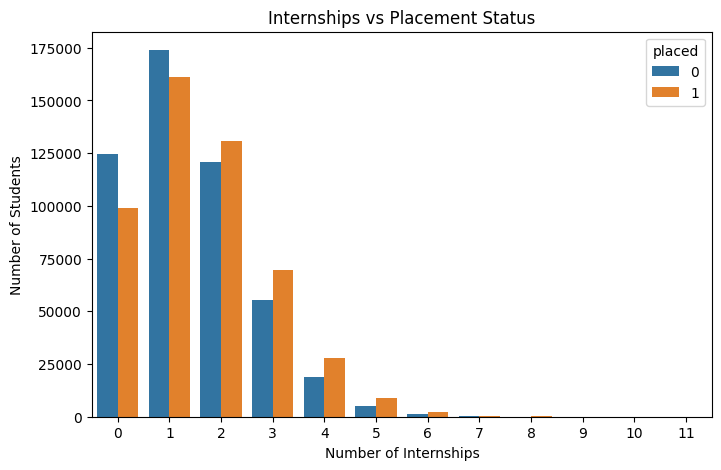

In [43]:
plt.figure(figsize=(8,5))

sns.countplot(x='internships', hue='placed', data=df)

plt.title('Internships vs Placement Status')
plt.xlabel('Number of Internships')
plt.ylabel('Number of Students')
plt.show()

Students with higher internship tends to have more chances of getting placed rather than the one who do not have an outer exposure.

**Placement Percentage**

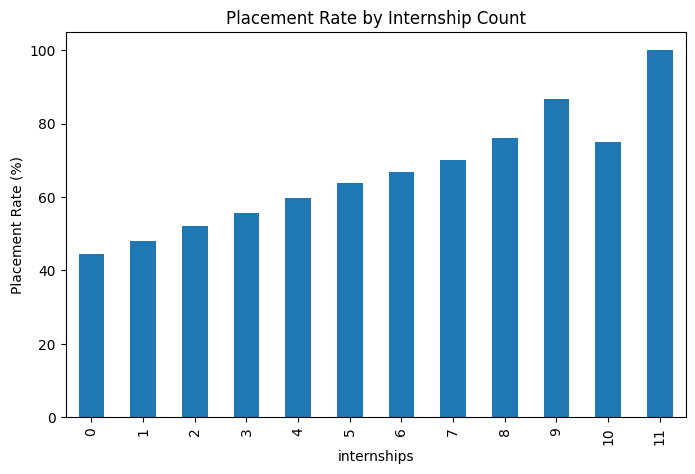

In [44]:
internship_placement = df.groupby('internships')['placed'].mean()*100

plt.figure(figsize=(8,5))

internship_placement.plot(kind='bar')

plt.title("Placement Rate by Internship Count")
plt.ylabel("Placement Rate (%)")

plt.show()


*   Higher placement rate as the no. of the internship goes higher.
*   And to clarify the 100% placement percnetage is actually very very low,    only few student were able to do that.

**Python Skill vs Placement**

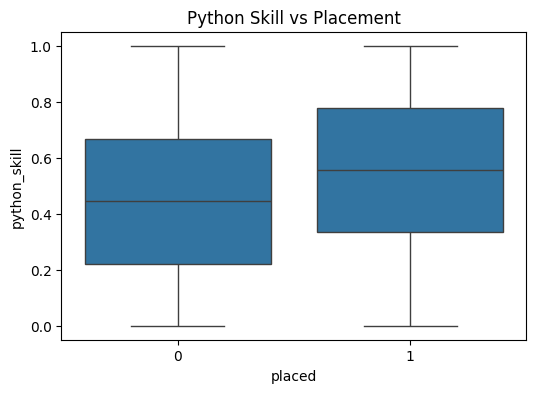

In [45]:
plt.figure(figsize=(6,4))
sns.boxplot(x='placed', y='python_skill', data=df)
plt.title("Python Skill vs Placement")
plt.show()

Skill plays a important role in placement of the student as shown in the graph.

**Backlogs vs Placement**

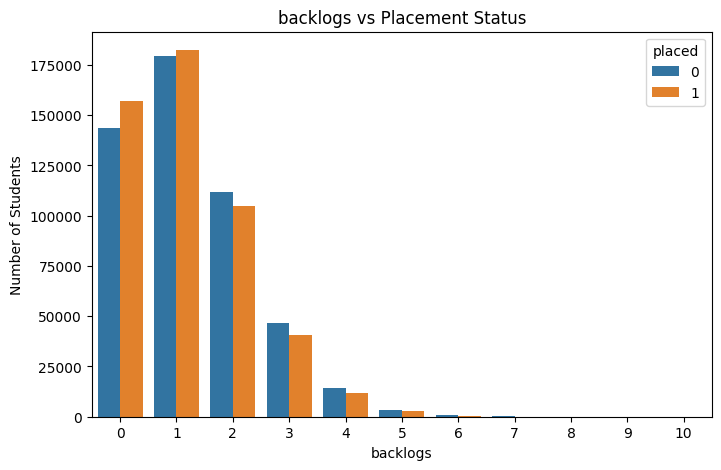

In [46]:
plt.figure(figsize=(8,5))

sns.countplot(x='backlogs', hue='placed', data=df)

plt.title('backlogs vs Placement Status')
plt.xlabel('backlogs')
plt.ylabel('Number of Students')
plt.show()

Students with fewer backlogs are more likely to get placed.

**Projects vs Placement**

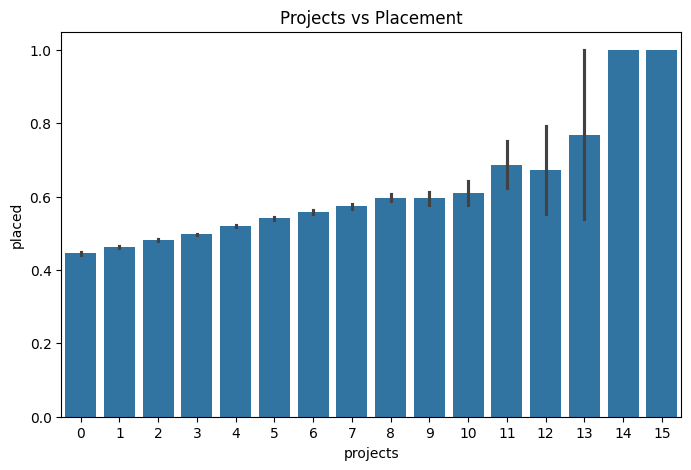

In [47]:
plt.figure(figsize=(8,5))
sns.barplot(x='projects', y='placed', data=df)
plt.title("Projects vs Placement")
plt.show()

**Aptitude Score vs Placement**

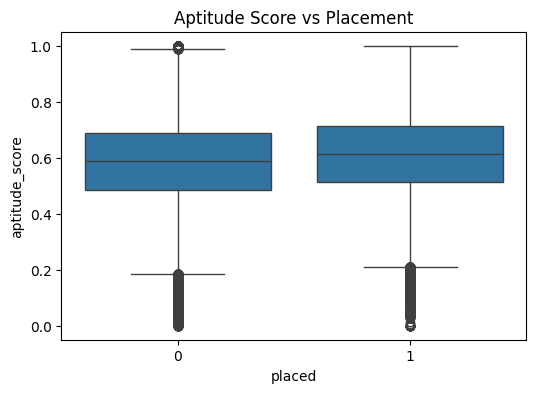

In [48]:
plt.figure(figsize=(6,4))
sns.boxplot(x='placed',
            y='aptitude_score',
            data=df)

plt.title('Aptitude Score vs Placement')
plt.show()


**Placement Rate by Branch**

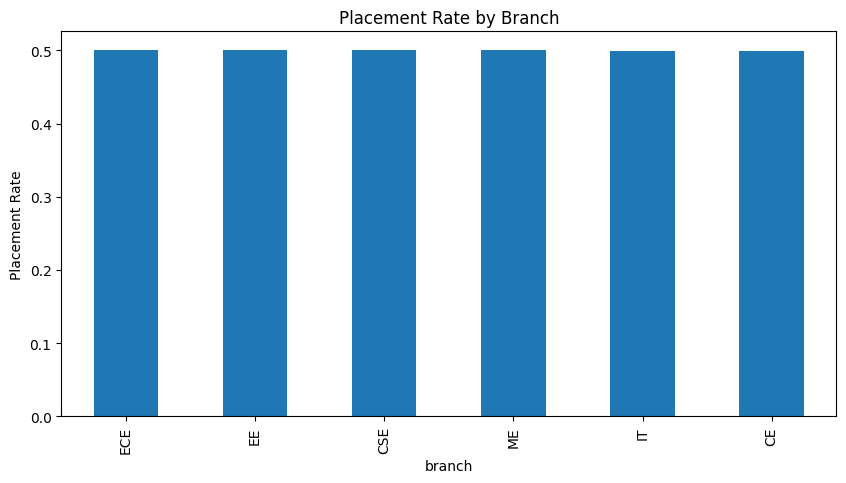

In [49]:
branch_rate = (
    df.groupby('branch')['placed']
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))
branch_rate.plot(kind='bar')
plt.title('Placement Rate by Branch')
plt.ylabel('Placement Rate')
plt.show()

**Coding Contest Rating vs Placement**

<Axes: xlabel='coding_contest_rating', ylabel='Count'>

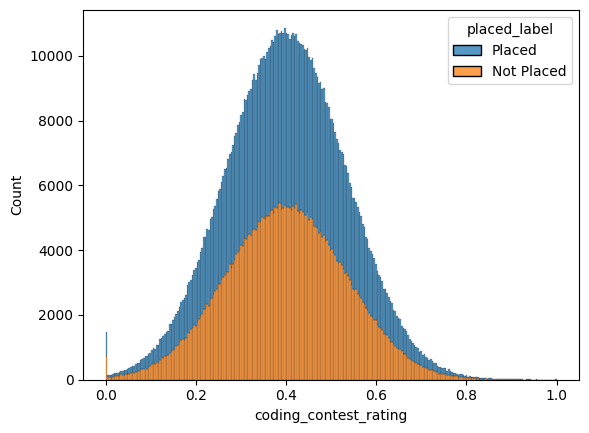

In [50]:
df['placed_label'] = df['placed'].map({0: 'Not Placed', 1: 'Placed'})
sns.histplot(
    data=df,

   x='coding_contest_rating',
    hue='placed_label',
    multiple='stack'
)

**Correlation Heatmap**

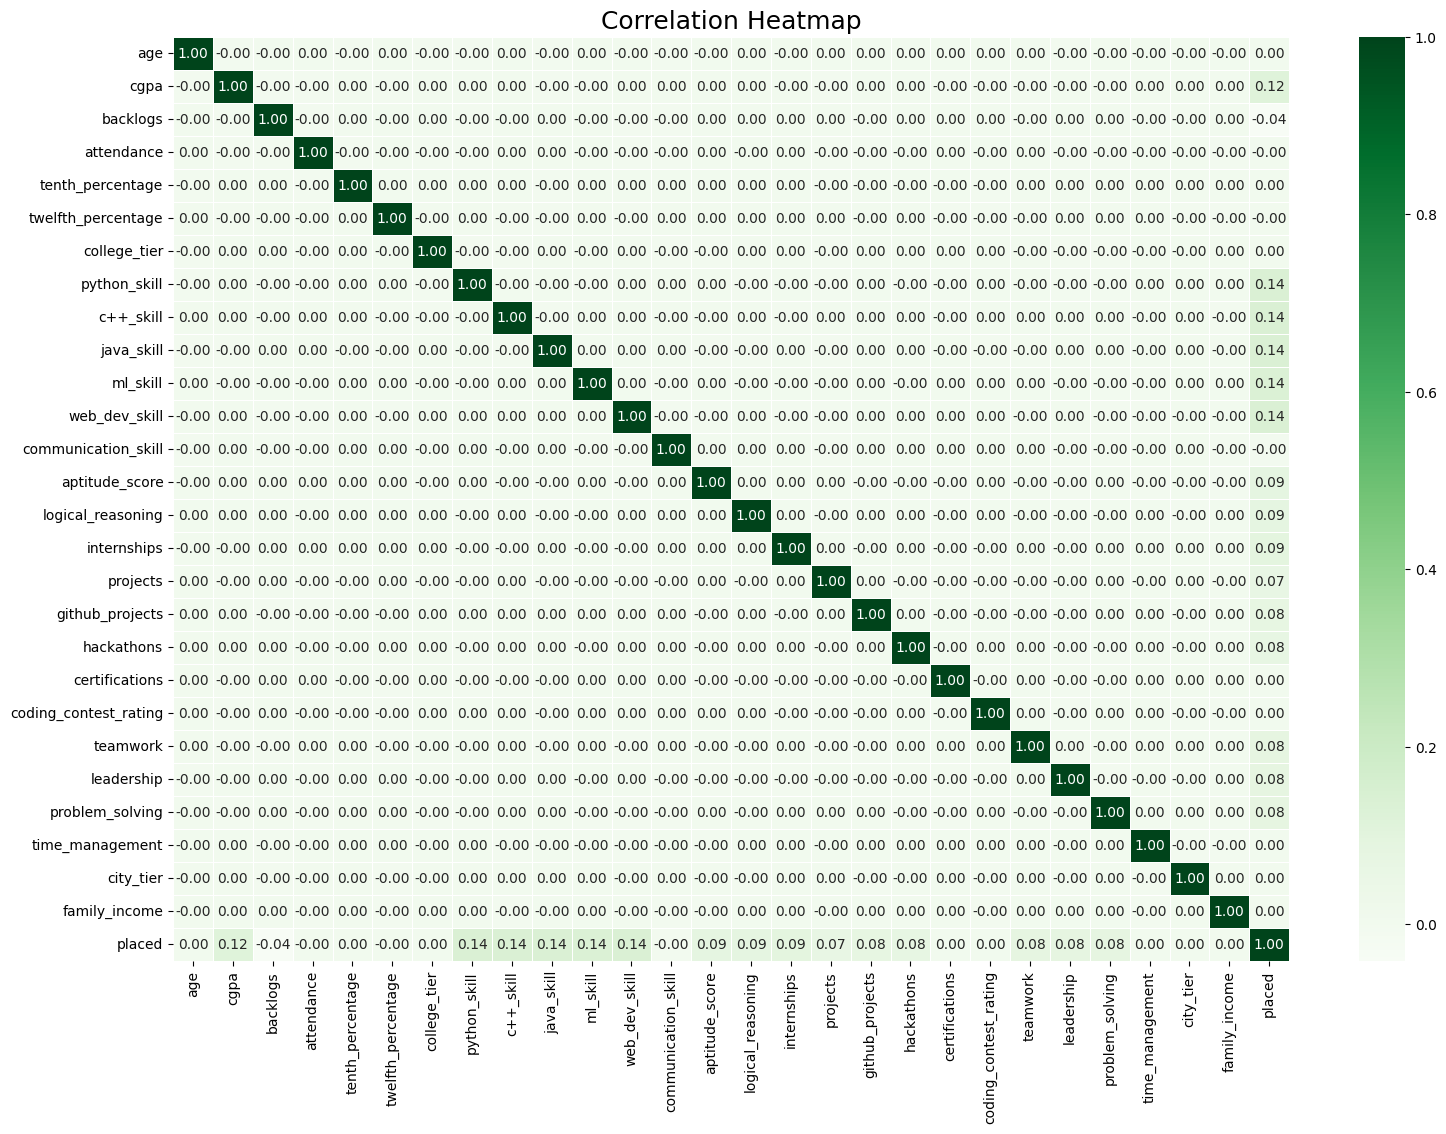

In [51]:
plt.figure(figsize=(18,12))

sns.heatmap( df.corr(numeric_only=True),
    annot=True,
    cmap='Greens',
    fmt='.2f',
    linewidths=0.5
)

plt.title("Correlation Heatmap", fontsize=18)

plt.show()

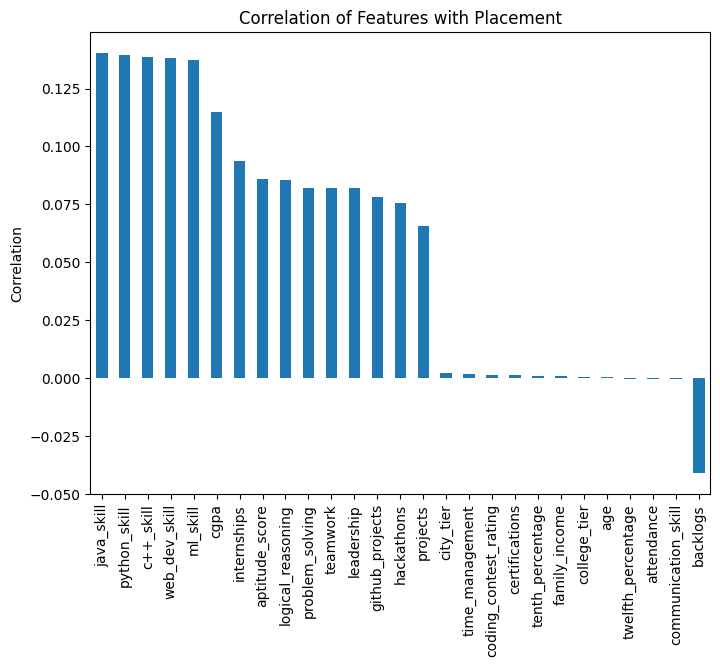

In [52]:
corr = df.corr(numeric_only=True)['placed'].sort_values(ascending=False)

plt.figure(figsize=(8,6))
corr.drop('placed').plot(kind='bar')
plt.title('Correlation of Features with Placement')
plt.ylabel('Correlation')
plt.show()

*  No single feature strongly determines placement.

*  Placement likely depends on a combination of multiple factors rather than one dominant variable.st item